In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

https\\www.ilae.org/congresses/36th-international-epilepsy-congress/section/sectionid/2

# Sleep Stages Duration and Spike rate in each sleep stage

In [2]:
stage_spike_occ_rate_datapath = Path("C:\\Users\\HFO\\Development\\pyeeg_toolbox\\Vectorized_WdwAn_Output\\Stage_Spike_Occurrence_Rate")

pats_ls = [
    "pat_FR_253_StageSpikeOccurrenceRate.csv",
    "pat_FR_970_StageSpikeOccurrenceRate.csv",
    "pat_FR_1084_StageSpikeOccurrenceRate.csv",
    "pat_FR_1096_StageSpikeOccurrenceRate.csv",
    "pat_FR_548_StageSpikeOccurrenceRate.csv",
    "pat_FR_1073_StageSpikeOccurrenceRate.csv",
    "pat_FR_1125_StageSpikeOccurrenceRate.csv",
]

In [3]:
stage_spike_data = pd.DataFrame()
for pdata_fn in pats_ls:
    data_fpath = stage_spike_occ_rate_datapath / pdata_fn
    print(data_fpath)
    try:
        pdata_df = pd.read_csv(data_fpath)
        stage_spike_data = pd.concat([stage_spike_data, pdata_df])
    except:
        print(f"File {pdata_fn} not found")
stage_spike_data

C:\Users\HFO\Development\pyeeg_toolbox\Vectorized_WdwAn_Output\Stage_Spike_Occurrence_Rate\pat_FR_253_StageSpikeOccurrenceRate.csv
C:\Users\HFO\Development\pyeeg_toolbox\Vectorized_WdwAn_Output\Stage_Spike_Occurrence_Rate\pat_FR_970_StageSpikeOccurrenceRate.csv
C:\Users\HFO\Development\pyeeg_toolbox\Vectorized_WdwAn_Output\Stage_Spike_Occurrence_Rate\pat_FR_1084_StageSpikeOccurrenceRate.csv
C:\Users\HFO\Development\pyeeg_toolbox\Vectorized_WdwAn_Output\Stage_Spike_Occurrence_Rate\pat_FR_1096_StageSpikeOccurrenceRate.csv
C:\Users\HFO\Development\pyeeg_toolbox\Vectorized_WdwAn_Output\Stage_Spike_Occurrence_Rate\pat_FR_548_StageSpikeOccurrenceRate.csv
C:\Users\HFO\Development\pyeeg_toolbox\Vectorized_WdwAn_Output\Stage_Spike_Occurrence_Rate\pat_FR_1073_StageSpikeOccurrenceRate.csv
C:\Users\HFO\Development\pyeeg_toolbox\Vectorized_WdwAn_Output\Stage_Spike_Occurrence_Rate\pat_FR_1125_StageSpikeOccurrenceRate.csv


,PatID,Stage,SpikeOccRate
0,pat_FR_253,N3,47.700000
1,pat_FR_253,N2,32.759777
2,pat_FR_253,N1,20.226519
3,pat_FR_253,REM,7.665025
4,pat_FR_253,Wake,9.392148
0,pat_FR_970,N3,5.201357
1,pat_FR_970,N2,4.405930
2,pat_FR_970,N1,3.189655
3,pat_FR_970,REM,4.175036
4,pat_FR_970,Wake,8.121876


Text(0.5, 1.0, 'Nr.Patients = 7')

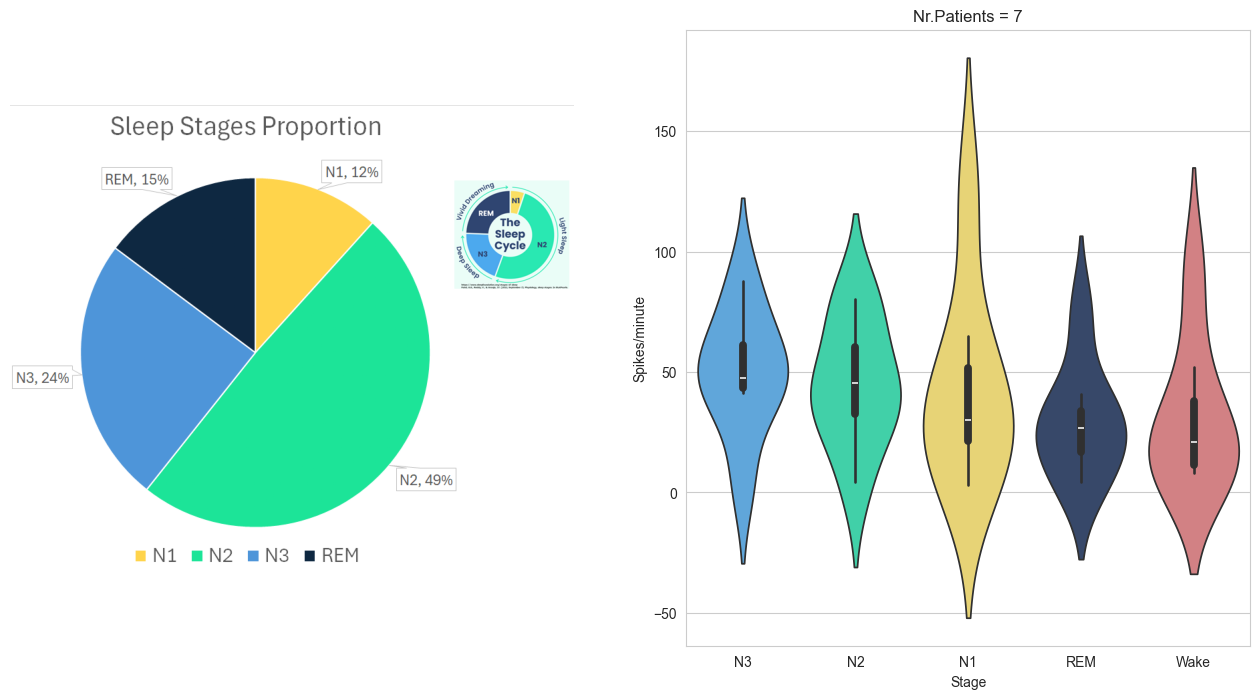

In [4]:
#plt.style.use('seaborn-v0_8-darkgrid')
sns.set_style("whitegrid")
FIGSIZE = (16, 8)
STAGES_COLORS = {'N1':(250,223,99), 'N2':(41,232,178), 'N3':(76,169,238), 'REM':(47,69,113), 'Wake':(224,115,120), 'Unknown':(128,128,128)}

for k,v in STAGES_COLORS.items():
    STAGES_COLORS[k] = (v[0]/255, v[1]/255, v[2]/255)

sleep_stages_duration_fpath = Path("C:\\Users\\HFO\\Documents\\Postdoc_Calgary\\Conferences\\ILAES_2025\\Duration_Of_Sleep_Stages.png")
image = plt.imread(sleep_stages_duration_fpath)

fig, axs = plt.subplots(1, 2, figsize=FIGSIZE)
axs[0].imshow(image)
axs[0].axis('off')

nr_pats = len(stage_spike_data.PatID.unique())
sns.violinplot(data=stage_spike_data, x='Stage', y='SpikeOccRate', hue='Stage', palette=STAGES_COLORS, ax=axs[1])
axs[1].set_ylabel("Spikes/minute")
axs[1].set_title(f"Nr.Patients = {nr_pats}")


In [5]:
stage_spike_data[['Stage','SpikeOccRate']].groupby(['Stage']).mean()

,SpikeOccRate
Stage,
N1,43.608802
N2,45.190036
N3,49.988369
REM,29.618615
Wake,31.664215


# Compare SOZ vs Non-SOZ

In [7]:
characterization_datapath = Path("C:\\Users\\HFO\\Development\\pyeeg_toolbox\\Vectorized_WdwAn_Output\\Spike_Characterized_Channels")
pats_ls = [
    "pat_FR_1125_AvgSpikeWdwActivity.csv",
    "pat_FR_253_AvgSpikeWdwActivity.csv",
    "pat_FR_548_AvgSpikeWdwActivity.csv",
    "pat_FR_970_AvgSpikeWdwActivity.csv",
    "pat_FR_1073_AvgSpikeWdwActivity.csv",
    "pat_FR_1084_AvgSpikeWdwActivity.csv",
    "pat_FR_1096_AvgSpikeWdwActivity.csv",
]

spike_data_df = pd.DataFrame()
for pdata_fn in pats_ls:
    data_fpath = characterization_datapath / pdata_fn
    print(data_fpath)
    pdata_df = pd.read_csv(data_fpath)
    #pdata_df.Amplitude = stats.zscore(pdata_df.Amplitude)
    pdata_df.Amplitude = MinMaxScaler().fit_transform(pdata_df.Amplitude.values.reshape(-1, 1))
    pdata_df['Patient'] = pdata_fn.replace('_AvgSpikeWdwActivity.csv', '')
    spike_data_df = pd.concat([spike_data_df, pdata_df])

spike_data_df.loc[spike_data_df.SOZ==1, 'SOZ'] = 'SOZ'
spike_data_df.loc[spike_data_df.SOZ==0, 'SOZ'] = 'Non-SOZ'

C:\Users\HFO\Development\pyeeg_toolbox\Vectorized_WdwAn_Output\Spike_Characterized_Channels\pat_FR_1125_AvgSpikeWdwActivity.csv
C:\Users\HFO\Development\pyeeg_toolbox\Vectorized_WdwAn_Output\Spike_Characterized_Channels\pat_FR_253_AvgSpikeWdwActivity.csv
C:\Users\HFO\Development\pyeeg_toolbox\Vectorized_WdwAn_Output\Spike_Characterized_Channels\pat_FR_548_AvgSpikeWdwActivity.csv
C:\Users\HFO\Development\pyeeg_toolbox\Vectorized_WdwAn_Output\Spike_Characterized_Channels\pat_FR_970_AvgSpikeWdwActivity.csv
C:\Users\HFO\Development\pyeeg_toolbox\Vectorized_WdwAn_Output\Spike_Characterized_Channels\pat_FR_1073_AvgSpikeWdwActivity.csv
C:\Users\HFO\Development\pyeeg_toolbox\Vectorized_WdwAn_Output\Spike_Characterized_Channels\pat_FR_1084_AvgSpikeWdwActivity.csv
C:\Users\HFO\Development\pyeeg_toolbox\Vectorized_WdwAn_Output\Spike_Characterized_Channels\pat_FR_1096_AvgSpikeWdwActivity.csv


C:\Users\HFO\AppData\Local\Temp\ipykernel_21828\3222800206.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'SOZ' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  spike_data_df.loc[spike_data_df.SOZ==1, 'SOZ'] = 'SOZ'


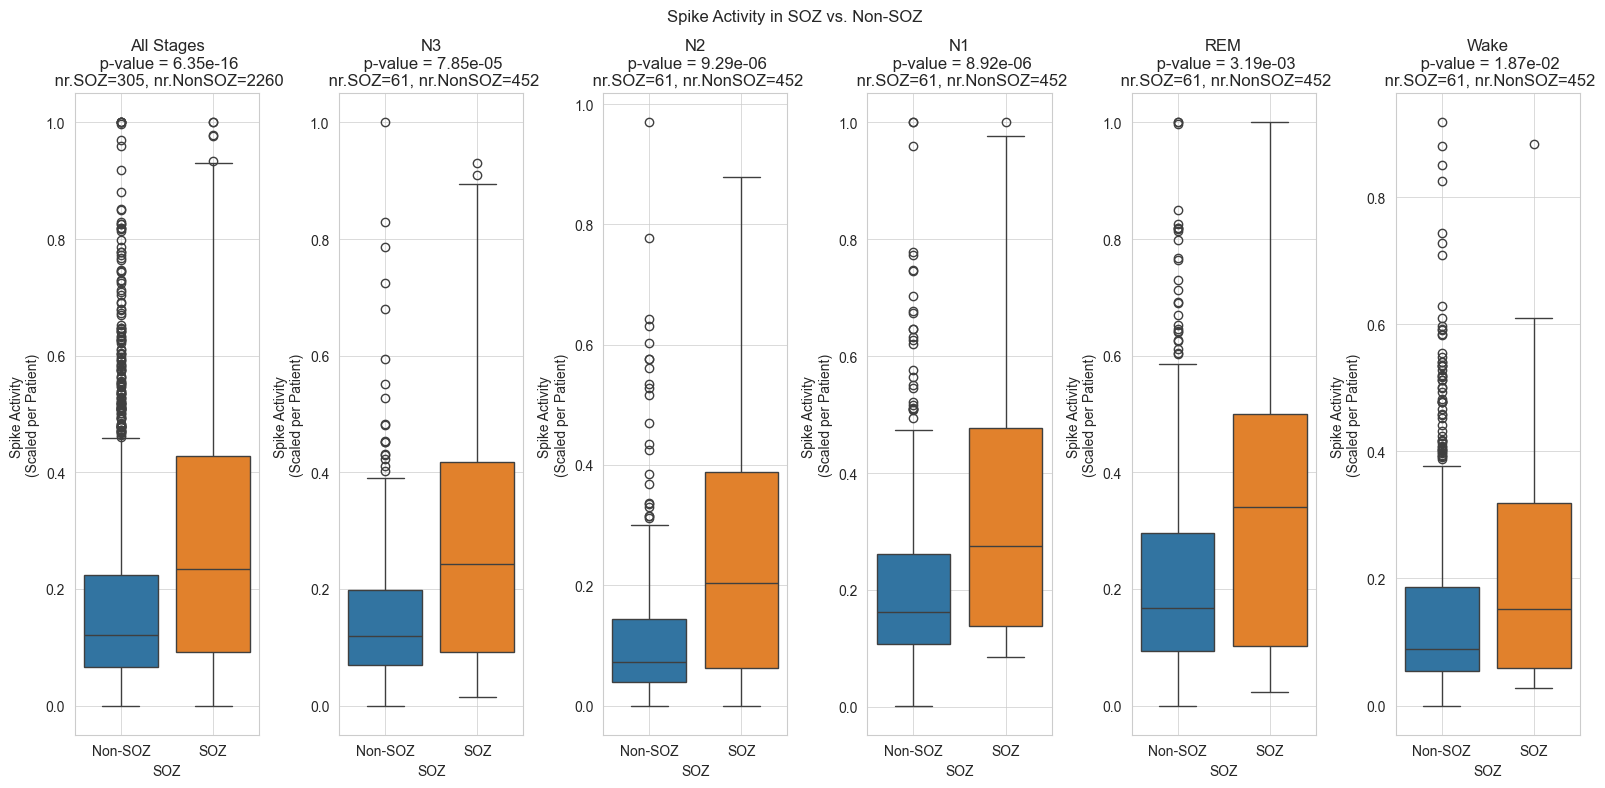

In [8]:
sleep_stages_ls = ['N3', 'N2', 'N1', 'REM', 'Wake']

fig, axs = plt.subplots(1, 6, figsize=FIGSIZE)

# All Stages
plt_ax = axs[0]
res = stats.mannwhitneyu(spike_data_df.Amplitude[spike_data_df.SOZ=='SOZ'], spike_data_df.Amplitude[spike_data_df.SOZ=='Non-SOZ'])
nr_soz = len(spike_data_df[spike_data_df.SOZ=='SOZ'])
nr_non_soz = len(spike_data_df[spike_data_df.SOZ=='Non-SOZ'])

#sns.violinplot(data=spike_data_df, x='SOZ', y='Amplitude', hue='SOZ', ax=axs[0])
sns.boxplot(data=spike_data_df, x='SOZ', y='Amplitude', hue='SOZ', ax=axs[0])
plt_ax.set_title(f"All Stages\n p-value = {res.pvalue:.2e}\n nr.SOZ={nr_soz}, nr.NonSOZ={nr_non_soz}")
plt_ax.set_ylabel("Spike Activity \n(Scaled per Patient)")
plt_ax.grid(color='0.8', linestyle='-', linewidth=0.5)

# Compare SOZ vs Non-SOZ in the different sleep stages
for si, stage_name in enumerate(sleep_stages_ls):
    plt_ax = axs[si+1]
    stage_data_df = spike_data_df[spike_data_df.Stage==stage_name]

    res = stats.mannwhitneyu(stage_data_df.Amplitude[stage_data_df.SOZ=='SOZ'], stage_data_df.Amplitude[stage_data_df.SOZ=='Non-SOZ'])
    
    nr_soz = len(stage_data_df[stage_data_df.SOZ=='SOZ'])
    nr_non_soz = len(stage_data_df[stage_data_df.SOZ=='Non-SOZ'])
    #sns.violinplot(data=stage_data_df, x='SOZ', y='Amplitude', hue='SOZ', ax=plt_ax)
    sns.boxplot(data=stage_data_df, x='SOZ', y='Amplitude', hue='SOZ', ax=plt_ax)

    plt_ax.set_title(f"{stage_name}\n p-value = {res.pvalue:.2e}\n nr.SOZ={nr_soz}, nr.NonSOZ={nr_non_soz}")
    plt_ax.set_ylabel("Spike Activity \n(Scaled per Patient)")
    plt_ax.grid(color='0.8', linestyle='-', linewidth=0.5)


plt.get_current_fig_manager().full_screen_toggle()
plt.suptitle(f"Spike Activity in SOZ vs. Non-SOZ")
plt.tight_layout()

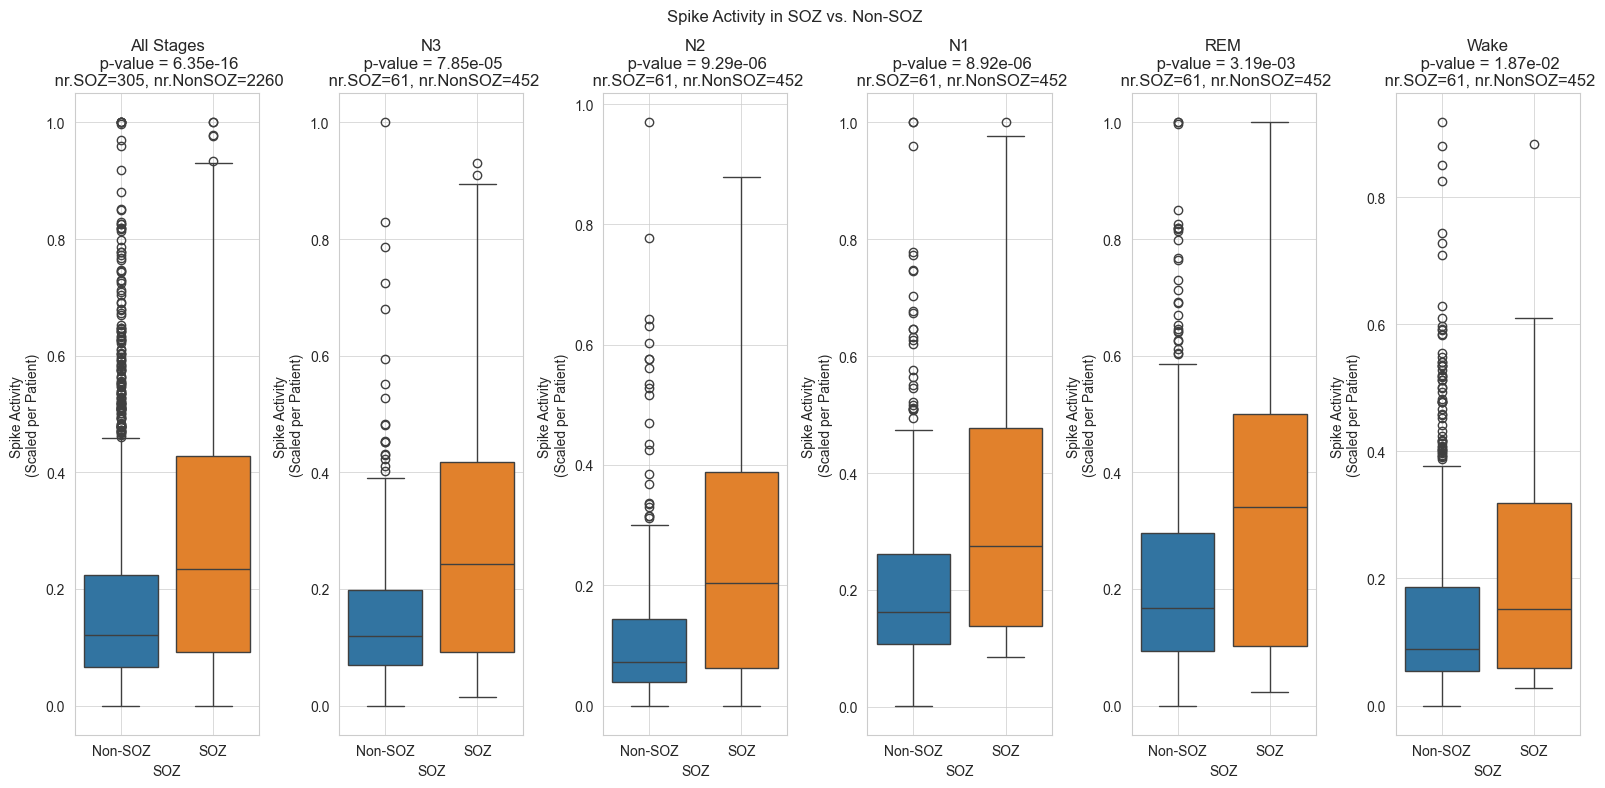

In [6]:

fig, axs = plt.subplots(1, 6, figsize=FIGSIZE)

sleep_stages_ls = ['N3', 'N2', 'N1', 'REM', 'Wake']
# All Stages
plt_ax = axs[0]
res = stats.mannwhitneyu(spike_data_df.Amplitude[spike_data_df.SOZ=='SOZ'], spike_data_df.Amplitude[spike_data_df.SOZ=='Non-SOZ'])
nr_soz = len(spike_data_df[spike_data_df.SOZ=='SOZ'])
nr_non_soz = len(spike_data_df[spike_data_df.SOZ=='Non-SOZ'])

#sns.violinplot(data=spike_data_df, x='SOZ', y='Amplitude', hue='SOZ', ax=axs[0])
sns.boxplot(data=spike_data_df, x='SOZ', y='Amplitude', hue='SOZ', ax=axs[0])
plt_ax.set_title(f"All Stages\n p-value = {res.pvalue:.2e}\n nr.SOZ={nr_soz}, nr.NonSOZ={nr_non_soz}")
plt_ax.set_ylabel("Spike Activity \n(Scaled per Patient)")
plt_ax.grid(color='0.8', linestyle='-', linewidth=0.5)

# Compare SOZ vs Non-SOZ in the different sleep stages
for si, stage_name in enumerate(sleep_stages_ls):
    plt_ax = axs[si+1]
    stage_data_df = spike_data_df[spike_data_df.Stage==stage_name]

    res = stats.mannwhitneyu(stage_data_df.Amplitude[stage_data_df.SOZ=='SOZ'], stage_data_df.Amplitude[stage_data_df.SOZ=='Non-SOZ'])
    
    nr_soz = len(stage_data_df[stage_data_df.SOZ=='SOZ'])
    nr_non_soz = len(stage_data_df[stage_data_df.SOZ=='Non-SOZ'])
    #sns.violinplot(data=stage_data_df, x='SOZ', y='Amplitude', hue='SOZ', ax=plt_ax)
    sns.boxplot(data=stage_data_df, x='SOZ', y='Amplitude', hue='SOZ', ax=plt_ax)

    plt_ax.set_title(f"{stage_name}\n p-value = {res.pvalue:.2e}\n nr.SOZ={nr_soz}, nr.NonSOZ={nr_non_soz}")
    plt_ax.set_ylabel("Spike Activity \n(Scaled per Patient)")
    plt_ax.grid(color='0.8', linestyle='-', linewidth=0.5)


plt.get_current_fig_manager().full_screen_toggle()
plt.suptitle(f"Spike Activity in SOZ vs. Non-SOZ")
plt.tight_layout()
